## Multicellular factor analysis of pathway activities

---
**NOTE**  
This notebook assumes familiarity with multicellular factor analysis and pathway activity inference.

---

Single-cell transcriptomics provides high-resolution measurements of gene expression, but interpretation at the gene level is often limited by noise, redundancy, and difficulty in linking signals to biological processes.

To address this, pathway activity inference methods summarize gene expression into **functional readouts of signaling or regulatory activity**. These features can provide a more interpretable representation of cellular states by aggregating information across sets of genes.

Here, we extend multicellular factor analysis to operate on **pathway activity estimates** instead of gene expression. This results in a factor model that captures **coordinated variation of biological processes across cell types and samples**, rather than individual genes.

This analysis option was presented in [scPAFA](https://www.nature.com/articles/s42003-024-07238-7). Here we demonstrate how `MOFA-FLEX` and `decoupler` facilitate the implementation of it with minimal changes to the code. 

---

### Core idea

Instead of modeling gene-level matrices, we construct a multi-view representation where each view contains **pathway activity scores** for a given cell type or compartment.

A factor model is then applied to this representation to learn:

- **Latent factors** capturing variation in pathway activity across samples  
- **Loadings** linking factors to specific pathways and cell types  

These factors can be interpreted as **multicellular programs of pathway activity**, reflecting coordinated regulation of biological processes across the tissue.

---

### Why use pathway activities?

Compared to gene-level models, pathway-based factor analysis:

- reduces dimensionality using **biologically informed features**  
- improves interpretability by linking factors directly to **pathways or regulatory programs**  
- increases robustness by aggregating signal across multiple genes  

This is particularly relevant in single-cell data, where gene-level noise can obscure higher-level biological structure.

---

### Relation to standard factor analysis

Conceptually, this approach follows the same principles as multicellular factor analysis:

- samples are represented across multiple views (cell types)  
- variation is decomposed into latent factors  

However, the key difference is that the input features are **pathway activities**, not genes. As a result:

- factors describe **variation in biological processes** rather than expression patterns  
- loadings are directly interpretable as **pathway contributions**  

---

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import decoupler as dc
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scanpy as sc
import mudata as md
import mofaflex as mf
import os
import mina

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



---

### Application to PBMC data

To illustrate the use of pathway information for multicellular modeling, here we apply MINA to a dataset of peripheral blood mononuclear cells (PBMCs) of eight individuals. In this dataset cells were sequenced before and after treatment with interferon beta ([Kang, et al., 2018](https://www.nature.com/articles/nbt.4042)).

Interferon beta is a type I interferon that signals through the Janus kinase/signal transducer and activator of transcription (JAK-STAT) pathway to trigger antiviral, antiproliferative, and immunomodulatory effects. 

In [PROGENy](https://www.nature.com/articles/s41467-017-02391-6) we have the gene expression changes caused by the stimulation of JAK-STAT, thus it is safe to assume that if we build a multicellular factor analysis using the pathway activities from PROGENy, factors associated with stimulation should include JAK-STAT

The code below shows the usual processing steps needed for this analysis

In [3]:
# Reading the data
adata = ad.read_h5ad("data/kang.h5ad")
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sample_key = 'replicate'
condition_key = 'label'
groupby = 'cell_type'

# create biosample_id by merging sample_key and condition_key
adata.obs[sample_key] = adata.obs[sample_key].astype(str)
adata.obs[condition_key] = adata.obs[condition_key].astype(str)
adata.obs["biosample_id"] = adata.obs[sample_key] + "_" + adata.obs[condition_key]

... storing 'label' as categorical
... storing 'replicate' as categorical


... storing 'biosample_id' as categorical


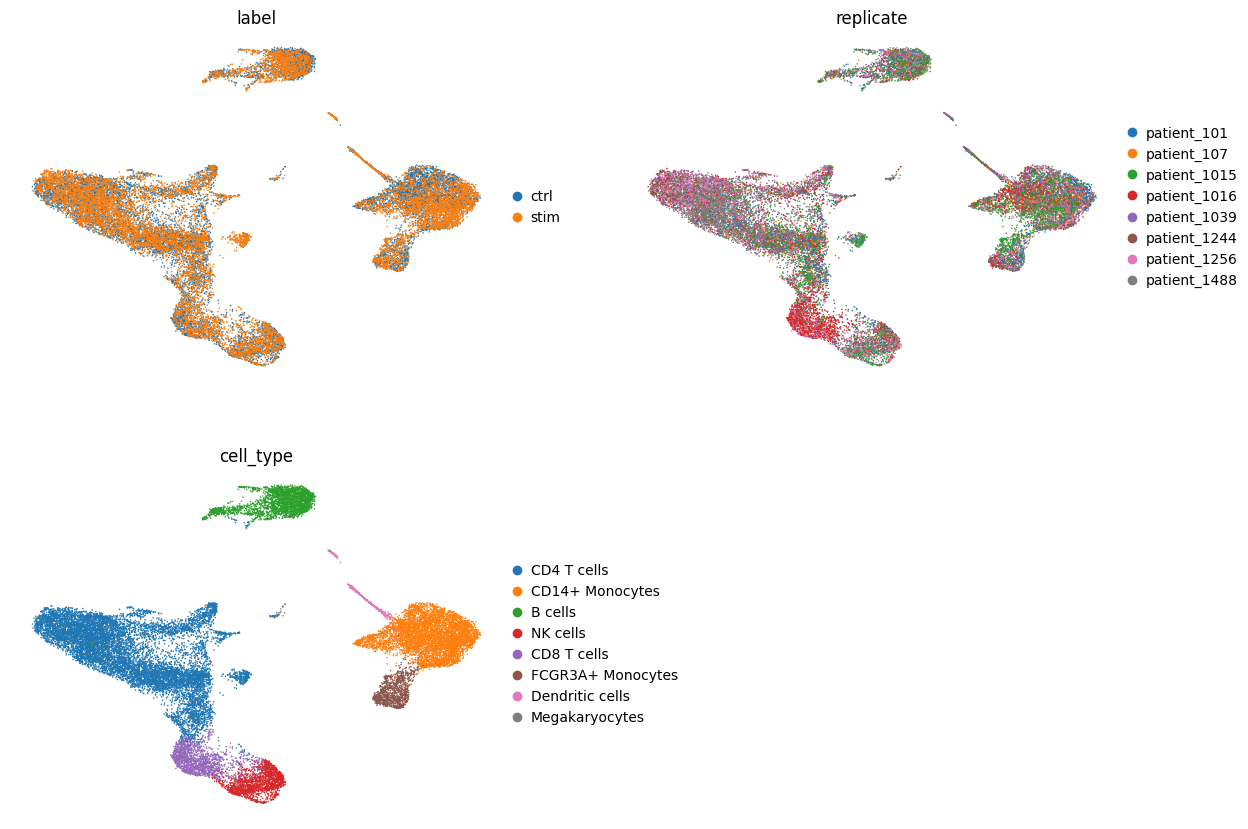

In [4]:
sc.pl.umap(adata, color=[condition_key, sample_key, groupby], frameon=False, ncols=2)

In [5]:
metadata = mina.up.pp.extract_metadata_from_obs(obs = adata.obs,
                                        groupby= 'biosample_id', 
                                        sort= False)

pdata = dc.pp.pseudobulk(adata, sample_col='biosample_id', groups_col="cell_type")

# Manipulations on pdata
pdata.obs = pdata.obs.set_index('biosample_id', drop=False)
pdata.obs.index.name = None 

anndata_dict = mina.up.split_anndata_by_celltype(pdata=pdata, grouping="cell_type")

# Adding gene expression total counts - TODO add to upstream as a function

for cell_type, adata in anndata_dict.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata.X, "toarray"):
        # Sparse matrix case
        total_counts = adata.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata.X.sum(axis=0)  # numpy array
    
    # Add to .var
    adata.var['total_counts'] = total_counts

mina.up.filt.filter_anndata_by_ncells(anndata_dict, min_cells=10)
# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata.index)
min_samples =  math.trunc((n_samples * 0.4))
mina.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.filter_genes_byexpr(anndata_dict, min_count=5, min_prop=0.4)
mina.up.filter_views_by_genes(anndata_dict, min_genes_per_view=100)
mina.up.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.90)
mina.up.save_raw_counts(anndata_dict, layer_name="raw_counts")
mina.up.norm_log(anndata_dict, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)

Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:795: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['patient_1015_ctrl', 'patient_1015_stim', 'patient_1016_ctrl', 'patient_1016_stim', 'patient_101_ctrl']

    Inferred to be: categorical



### Using decoupler to estimate pathway activities per view

Here we use the basic functions provided by `decoupler` to transform the gene expression of each view into pathway activities using PROGENy.

For those unfamiliar with this type of analyses, please refer to the rich documentation of [decoupler](https://decoupler.readthedocs.io/en/latest/)

In [6]:
progeny = dc.op.progeny(organism="human",top=200)
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
2792,p53,SGO1,-4.878325,2.398819e-09
2793,p53,KLC3,2.138088,2.434639e-09
2794,p53,RNASE7,4.776755,2.730602e-09
2795,p53,CDH10,5.802510,2.772294e-09


MINA provides a simple wrapper to compute pathway enrichment across views. By default, the same prior knowledge is applied to all views.

If view-specific pathway enrichment is required, one approach is to encode the view identity in the feature names (e.g. by appending the view label) and adjust the prior knowledge accordingly. In this setup, the `tmin` parameter can be used to filter pathways so that they are only retained for the intended view.

In [7]:
mina.up.convert_views_to_functions(anndata_dict, net=progeny, tmin=5)

### Fitting the model with MOFA-FLEX

No modifications to standard fitting is needed. Note that this modeling strategy is compatible with previous analyses (e.g. group modeling, guidance with covariates, etc.)

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
2026-03-31 11:30:13 | [WARNING] Device cuda is not available. Using default device: cpu


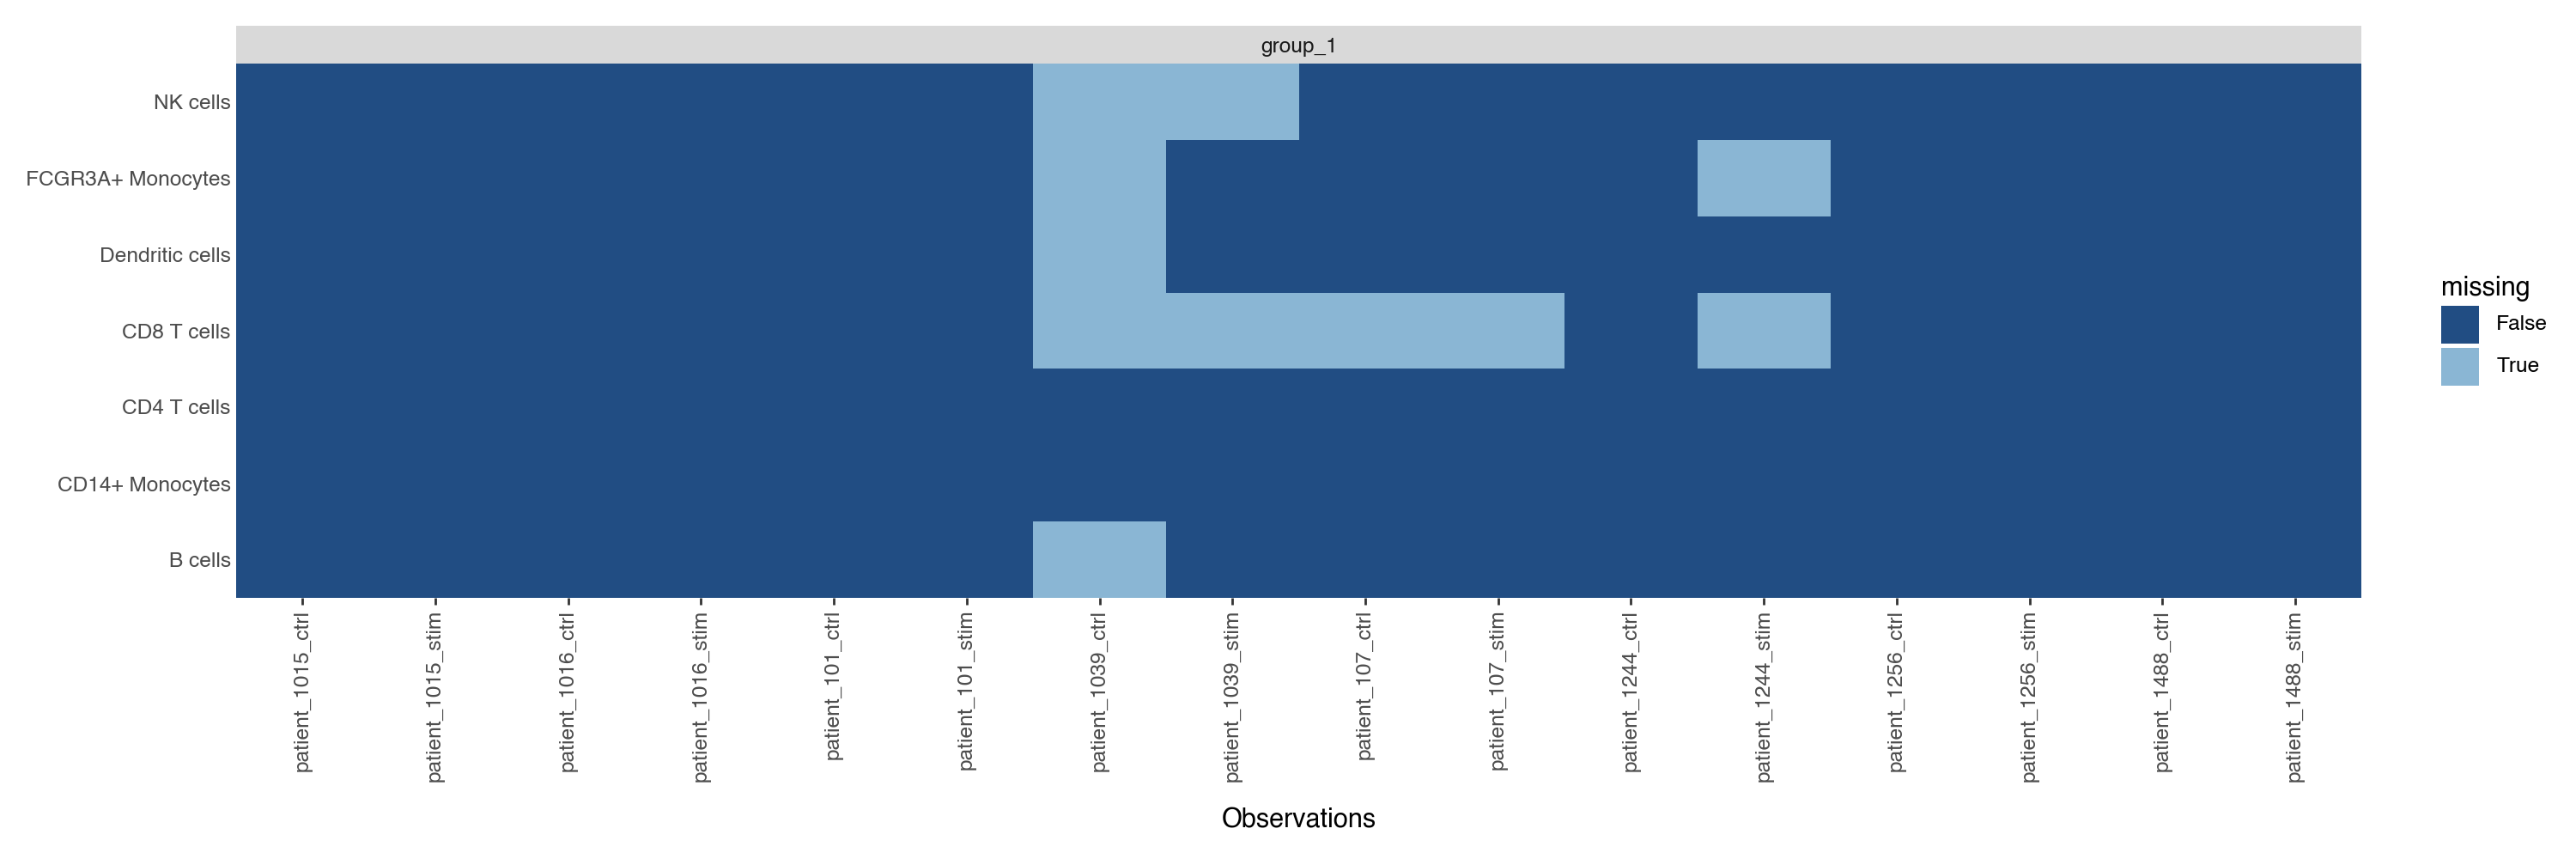

2026-03-31 11:30:13 | [WARNING] Could not import dask. Data arrays may be copied, resulting in high memory usage.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/an

In [8]:
# This is necessary before any model fit!
mina.up.utils.append_view_to_var(anndata_dict)

mdata = md.MuData(anndata_dict)
model = mf.MOFAFLEX(
    mdata,
    mf.ModelOptions(n_factors=3, weight_prior="SnS", likelihoods="Normal"),
    mf.TrainingOptions(seed=42, save_path=False, lr=0.01, early_stopper_patience=500)
)

### Outputs of a factor model

A factor model decomposes the data into **latent factors** (capturing sample-level variation) and **loadings** (capturing feature-level contributions), summarizing the main sources of variability.

This is unchanged from the basic workflow. This model produces the same outputs (factor scores, explained variance, and loadings), so all downstream functions in MINA can be applied in the same way. The only difference is that the features used in modeling are pathway activities

In [9]:
amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model,
)

In [10]:
# Characterizing Factor Loadings
# First we need to make the gene loadings a pandas DataFrame with named columns and indexes
# Wrap as DataFrame for readability - This could be a function - users will forget to do this
feature_loadings = pd.DataFrame(amodel.varm["gene_loadings"], columns=amodel.uns['gene_loadings_columns'])
feature_loadings.index = amodel.var.index.to_list()

# Make a dictionary of gene expression data
feature_loadings = mina.down.split_by_view(feature_loadings)

For example, let's look at the Factor loadings of B cells

In [12]:
feature_loadings["B cells"]

feature,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
Factor1,-0.298592,0.000025,-0.302892,0.269109,-1.339559e+00,-4.538640e-08,0.000005,0.000016,4.754002e-06,0.000006,-0.000033,6.299861e-09,-2.949589e-01,-0.000051
Factor2,0.000019,0.000002,0.000008,0.257427,-1.888178e+00,-1.397154e-09,-0.493433,-0.000008,2.218043e-06,-0.413292,-0.097462,1.510995e-06,-2.715312e-01,-0.000002
Factor3,0.000059,-0.245326,-0.042169,-0.000059,1.191879e-08,-3.735055e-01,-0.290119,-0.171321,2.119017e-20,-0.260076,0.204977,-3.605856e-12,-3.309477e-07,-0.176664


### Factor Associations

Here we test if there are factor activities associated with the perturbed samples

In [14]:
mina.down.get_associations(amodel, 
                           test_variable = "label",
                           test_type="categorical",
                           random_effect = None)

,feature,statistic,p_value,adj_p_value
0,Factor1,45.322121,0.000010,0.000014
1,Factor2,58.013538,0.000002,0.000007
2,Factor3,0.825105,0.379063,0.379063


Two factors associate with perturbation. In both, lower activities of the factor associate with the stimulation with interferon beta.

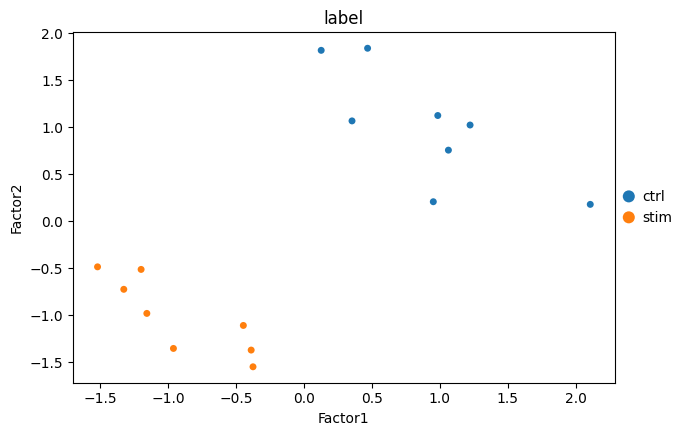

In [15]:
sc.pl.scatter(amodel,
              x = "Factor1",
              y = "Factor2", 
              color  = "label", 
              size =100)

We can explore how much explained variance these factors captured. (Given the smaller size of the feature space, these values are larger than what we observed before)

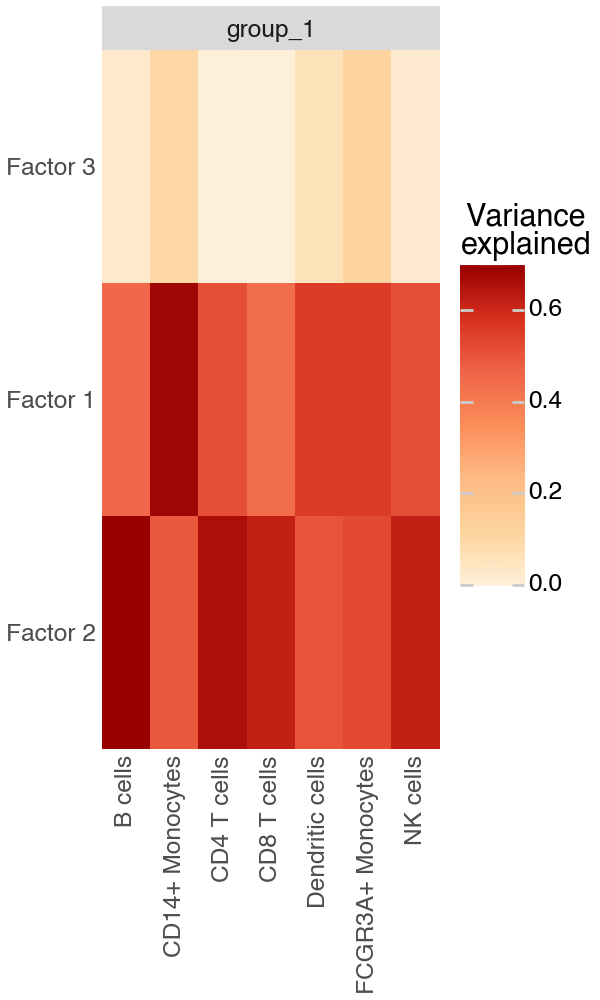

In [16]:
mf.pl.variance_explained(model)

To validate our assumptions, let's plot the pathway loadings for each factor. Note here that these are not the product of the enrichment of gene loadings as in previous tutorials. This is the importance of each pathway for each factor

/Users/flores/Dropbox/EBI/Research/MINA/src/mina/pl/pl.py:755: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


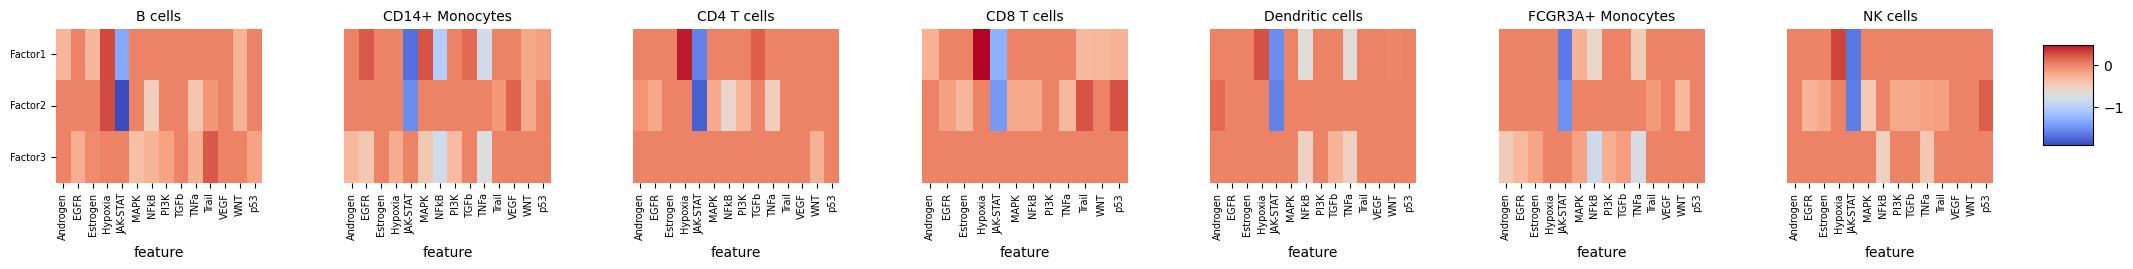

In [24]:
mina.pl.plot_features_per_view(df_dict=feature_loadings, features=progeny["source"].drop_duplicates().tolist(), figsize=(25, 2))

As expected. we observe that both factors associated with the stimulation present an activation of JAK-STAT (Remember that lower values of the factor 1 and 2 associated with stimulated samples).

---

## Summary

In this vignette, we applied multicellular factor analysis to model coordinated sample-level variation across circulatory cells before and after stimulation with interferon beta. The key difference from the introductory tutorial is the we exchange the features to model, from gene expression to pathway activity to facilitate interpretation of the factors.

The next vignette focus on a similar type of modeling, however, we will explicitly incorporate prior knowledge in the modeling.